# Atividade 3  — Codificação de Linha e Efeito do Canal Real de Transmissão

**Disciplina:** SCM22108 — Sistemas de Comunicação
**Curso:** Engenharia Eletrônica – IFSC, Florianópolis

## Contexto

Nas aulas anteriores vimos o modelo simplificado de um sistema de comunicação
(Fonte → Transmissor → Canal → Receptor → Destino) e como o canal — neste
caso, um cabo CAT5e — impõe uma atenuação que cresce com a frequência,
conforme a curva de *Insertion Loss* do datasheet do fabricante. Nesta
atividade você vai fechar essa cadeia de ponta a ponta: gerar um sinal
digital codificado em linha, e observar o que acontece com ele ao atravessar
um canal real modelado a partir de dados de catálogo.

Um LLM pode (e deve) ser usado como apoio na parte de implementação — do
mesmo jeito que você usaria o Google e/ou Stack
Overflow. O que será avaliado não é se o código roda, e sim se você entende
por que ele se comporta do jeito que se comporta.

Preencha as células de código ao longo deste notebook (marcadas com
`# TODO`) à medida que for desenvolvendo a atividade. As células de markdown
com respostas devem ser editadas com um duplo clique.

In [1]:
# Imports gerais (adicione outros que precisar)
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, welch

%matplotlib inline

## Seus parâmetros individuais

Antes de começar, calcule os seus parâmetros a partir dos **três últimos
dígitos da sua matrícula (RA)**, chamados aqui de `XYZ`:

- **Semente aleatória:** `seed = XYZ` (use essa semente ao gerar a
  sequência de bytes aleatória — `np.random.seed(seed)` ou equivalente —
  para que sua sequência seja reprodutível e diferente da dos colegas).
- **Comprimento de cabo a emular:** `length_m = 40 + (XYZ mod 60)` metros
  (em vez do 100 m padrão usado nos exemplos de aula).

Registre esses dois valores logo abaixo. Gráficos e conclusões gerados com a
semente/comprimento errados (ou com os valores padrão de exemplo) serão
considerados incompletos.

In [2]:
RA_XYZ = 875

seed = RA_XYZ
length_m = 40 + (RA_XYZ % 60) if RA_XYZ is not None else None

print("seed =", seed)
print("length_m =", length_m)

seed = 875
length_m = 75


## Parte 1 — Implementação das codificações de linha

Com o auxílio de um LLM, implemente funções para as seguintes codificações
de linha, todas recebendo uma sequência de bits e retornando o sinal em
banda base amostrado:

- Unipolar NRZ
- Unipolar RZ
- Bipolar (AMI) NRZ
- Bipolar (AMI) RZ
- Polar Quaternário NRZ (4 níveis, 2 bits por símbolo)

Sugestão de assinatura de função (ajuste como preferir):
`def codifica(bits, Rb, fs) -> (t, sinal)`, onde `Rb` é a taxa de
transmissão em bps e `fs` a taxa de amostragem usada para representar o
sinal continuamente.

In [3]:
def unipolar_nrz(bits, Rb, fs):
    samples_per_bit = int(fs / Rb)

    signal = np.repeat(bits, samples_per_bit)

    return signal

In [4]:
def unipolar_rz(bits, Rb, fs):
    samples_per_bit = int(fs / Rb)
    half_bit = samples_per_bit // 2

    signal = np.zeros(len(bits) * samples_per_bit)

    for i, bit in enumerate(bits):
        if bit == 1:
            start = i * samples_per_bit
            signal[start:start + half_bit] = 1

    return signal

In [5]:
def bipolar_nrz(bits, Rb, fs):
    samples_per_bit = int(fs / Rb)

    signal = np.zeros(len(bits) * samples_per_bit)

    polarity = 1

    for i, bit in enumerate(bits):
        if bit == 1:
            start = i * samples_per_bit
            end = start + samples_per_bit

            signal[start:end] = polarity

            polarity *= -1

    return signal

In [6]:
def bipolar_rz(bits, Rb, fs):
    samples_per_bit = int(fs / Rb)
    half_bit = samples_per_bit // 2

    signal = np.zeros(len(bits) * samples_per_bit)

    polarity = 1

    for i, bit in enumerate(bits):
        if bit == 1:
            start = i * samples_per_bit

            signal[start:start + half_bit] = polarity

            polarity *= -1

    return signal

In [7]:
def polar_quaternario_nrz(bits, Rb, fs):
    samples_per_bit = int(fs / Rb)

    # Garante quantidade par de bits
    if len(bits) % 2 != 0:
        bits = np.append(bits, 0)

    signal = []

    for i in range(0, len(bits), 2):

        pair = (bits[i], bits[i + 1])

        if pair == (0, 0):
            level = -3
        elif pair == (0, 1):
            level = -1
        elif pair == (1, 0):
            level = 1
        else:
            level = 3

        signal.extend([level] * (2 * samples_per_bit))

    return np.array(signal)

### Log de uso de IA (Parte 1)

Anexe abaixo um **log resumido de uso de IA**: para cada codificação (ou
grupo delas, se você pediu tudo de uma vez), qual foi o prompt usado, o que
a IA retornou, e o que você precisou corrigir, ajustar ou reescrever para o
código funcionar corretamente (mesmo que a resposta tenha vindo certa de
primeira — diga isso também). Trate esse log como citação de fonte, não
como confissão: o objetivo é documentar seu processo de validação, não
desencorajar o uso da ferramenta.

**Prompt 1: Perfeito. Vamos começar então. Temos que implementar essas funções {funções TODO}** 

**O que a IA retornou: Além da explicação a fundo de cada implementação, retornou as funções pedidas.** 

## Parte 2 — Geração do sinal e análise no domínio do tempo e da frequência

1. Gere uma sequência aleatória de **100 bytes** (800 bits) usando a sua
   semente individual.
2. Para cada uma das cinco codificações da Parte 1, com `Rb = 10 Mbps`,
   plote:
   - o sinal no domínio do tempo (um trecho representativo, não os 800 bits
     inteiros);
   - a densidade espectral de potência (PSD) do sinal.
3. Para o sinal NRZ, observe que cada lóbulo do espectro tem largura
   `Δf = 1/T_b = Rb`, e que os primeiros lóbulos concentram a maior parte da
   energia do sinal.

In [8]:
np.random.seed(seed)

bits = np.random.randint(0, 2, size=800)

print("Número de bits:", len(bits))
print("Primeiros bits:", bits[:20])

Número de bits: 800
Primeiros bits: [0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 1 1 1 1 1]


In [9]:
# Frequência de amostragem
fs = 100e6  # 100 MHz
Rb = 10e6

print(f"fs = {fs/1e6:.0f} MHz")
print(f"Amostras por bit = {fs/Rb:.0f}")

fs = 100 MHz
Amostras por bit = 10


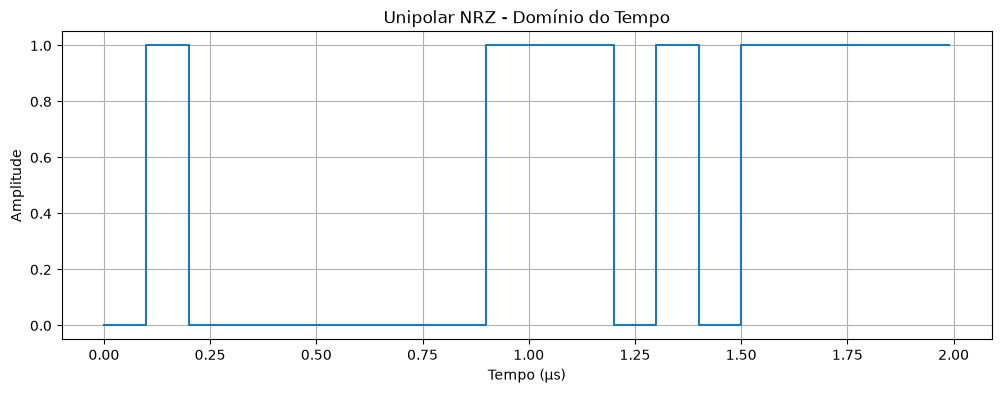

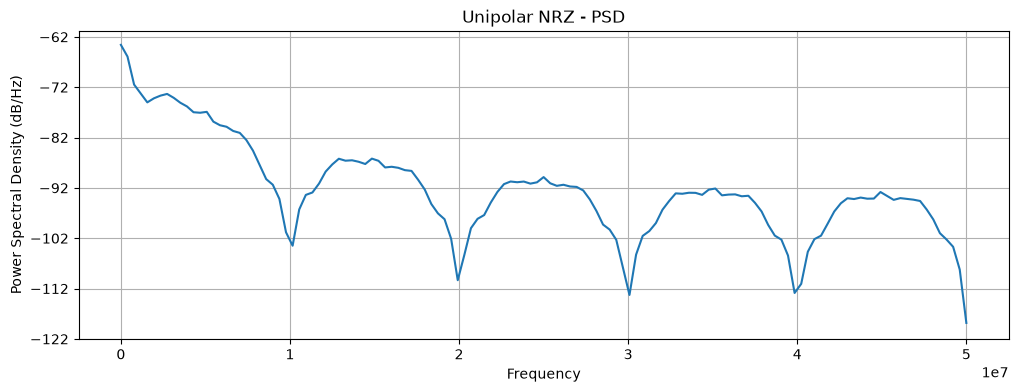

In [10]:
sinal_nrz = unipolar_nrz(bits, Rb, fs)

# Eixo de tempo
t = np.arange(len(sinal_nrz)) / fs

# -------------------------
# Domínio do tempo
# -------------------------
N_bits_plot = 20
N_amostras_plot = N_bits_plot * int(fs / Rb)

plt.figure(figsize=(12, 4))
plt.plot(
    t[:N_amostras_plot] * 1e6,
    sinal_nrz[:N_amostras_plot],
    drawstyle="steps-post"
)
plt.xlabel("Tempo (µs)")
plt.ylabel("Amplitude")
plt.title("Unipolar NRZ - Domínio do Tempo")
plt.grid()
plt.show()

# -------------------------
# PSD
# -------------------------
plt.figure(figsize=(12, 4))
plt.psd(sinal_nrz, Fs=fs)
plt.title("Unipolar NRZ - PSD")
plt.show()

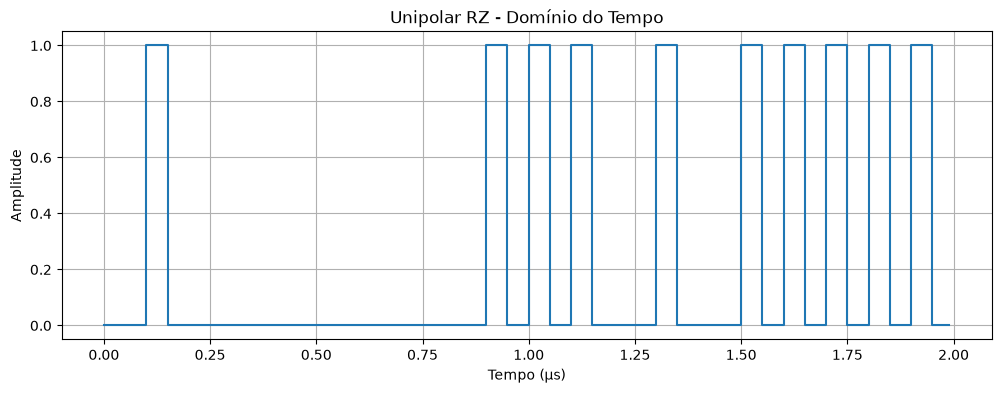

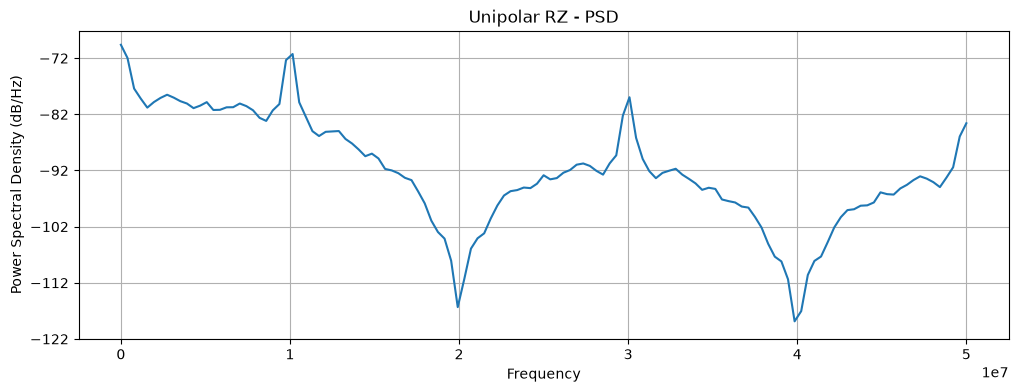

In [11]:
Rb = 10e6

sinal_rz = unipolar_rz(bits, Rb, fs)

# Eixo de tempo
t = np.arange(len(sinal_rz)) / fs

# -------------------------
# Domínio do tempo
# -------------------------
N_bits_plot = 20
N_amostras_plot = N_bits_plot * int(fs / Rb)

plt.figure(figsize=(12, 4))
plt.plot(
    t[:N_amostras_plot] * 1e6,
    sinal_rz[:N_amostras_plot],
    drawstyle="steps-post"
)
plt.xlabel("Tempo (µs)")
plt.ylabel("Amplitude")
plt.title("Unipolar RZ - Domínio do Tempo")
plt.grid()
plt.show()

# -------------------------
# PSD
# -------------------------
plt.figure(figsize=(12, 4))
plt.psd(sinal_rz, Fs=fs)
plt.title("Unipolar RZ - PSD")
plt.show()

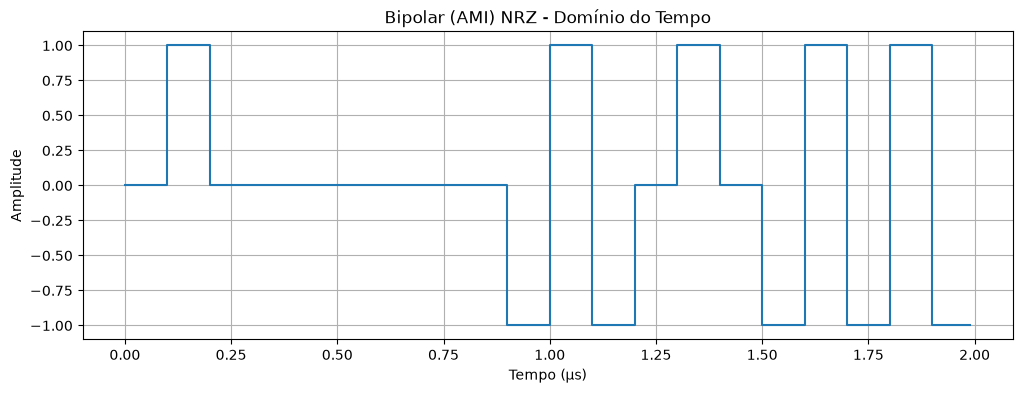

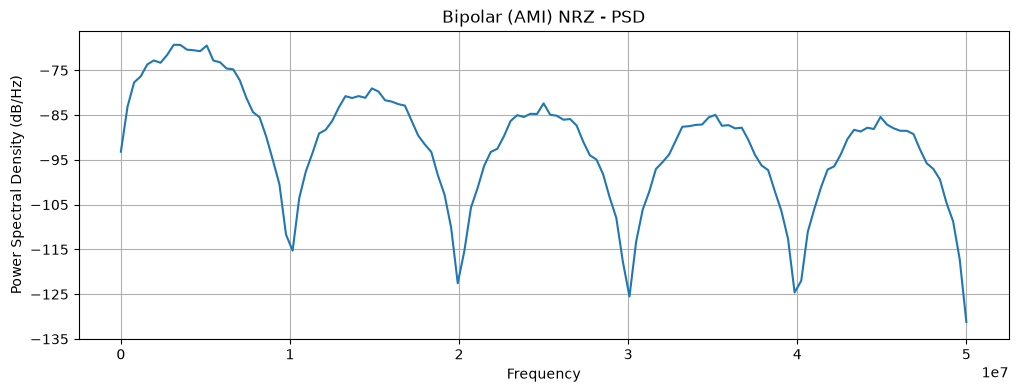

In [12]:
Rb = 10e6

sinal_ami_nrz = bipolar_nrz(bits, Rb, fs)

# Eixo de tempo
t = np.arange(len(sinal_ami_nrz)) / fs

# -------------------------
# Domínio do tempo
# -------------------------
N_bits_plot = 20
N_amostras_plot = N_bits_plot * int(fs / Rb)

plt.figure(figsize=(12, 4))
plt.plot(
    t[:N_amostras_plot] * 1e6,
    sinal_ami_nrz[:N_amostras_plot],
    drawstyle="steps-post"
)
plt.xlabel("Tempo (µs)")
plt.ylabel("Amplitude")
plt.title("Bipolar (AMI) NRZ - Domínio do Tempo")
plt.grid()
plt.show()

# -------------------------
# PSD
# -------------------------
plt.figure(figsize=(12, 4))
plt.psd(sinal_ami_nrz, Fs=fs)
plt.title("Bipolar (AMI) NRZ - PSD")
plt.show()

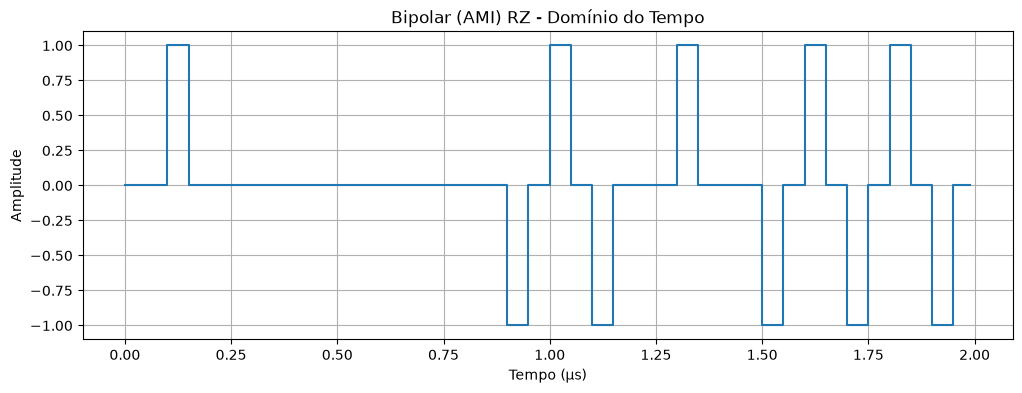

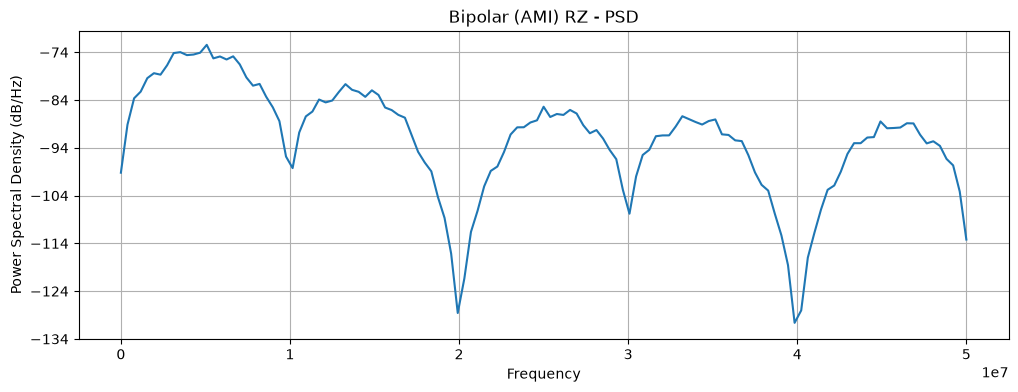

In [13]:
Rb = 10e6

sinal_ami_rz = bipolar_rz(bits, Rb, fs)

# Eixo de tempo
t = np.arange(len(sinal_ami_rz)) / fs

# -------------------------
# Domínio do tempo
# -------------------------
N_bits_plot = 20
N_amostras_plot = N_bits_plot * int(fs / Rb)

plt.figure(figsize=(12, 4))
plt.plot(
    t[:N_amostras_plot] * 1e6,
    sinal_ami_rz[:N_amostras_plot],
    drawstyle="steps-post"
)
plt.xlabel("Tempo (µs)")
plt.ylabel("Amplitude")
plt.title("Bipolar (AMI) RZ - Domínio do Tempo")
plt.grid()
plt.show()

# -------------------------
# PSD
# -------------------------
plt.figure(figsize=(12, 4))
plt.psd(sinal_ami_rz, Fs=fs)
plt.title("Bipolar (AMI) RZ - PSD")
plt.show()

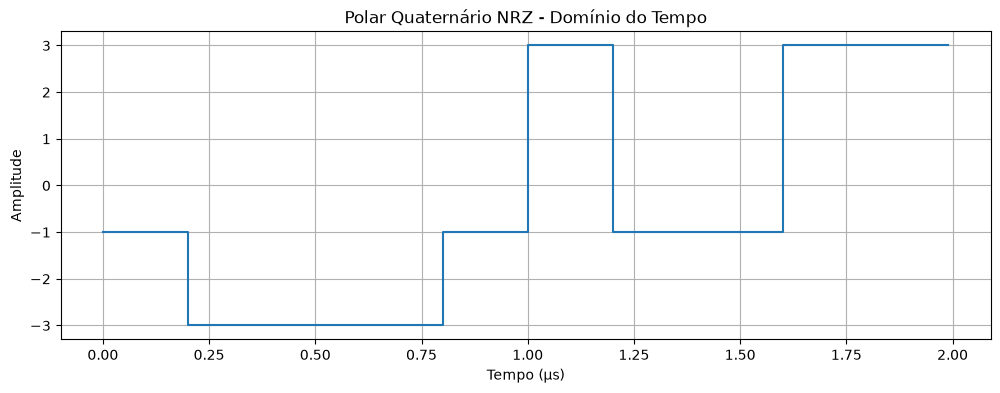

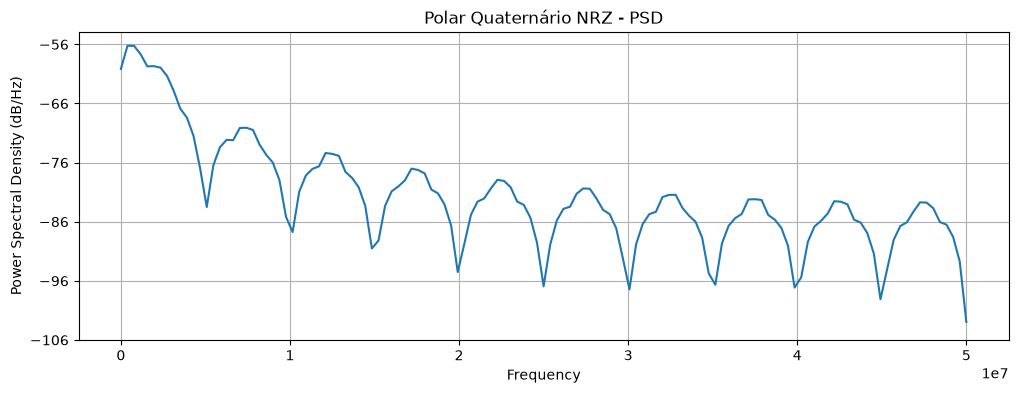

In [14]:
Rb = 10e6

sinal_polar_4 = polar_quaternario_nrz(bits, Rb, fs)

# Eixo de tempo
t = np.arange(len(sinal_polar_4)) / fs

# -------------------------
# Domínio do tempo
# -------------------------
N_bits_plot = 20
N_amostras_plot = N_bits_plot * int(fs / Rb)

plt.figure(figsize=(12, 4))
plt.plot(
    t[:N_amostras_plot] * 1e6,
    sinal_polar_4[:N_amostras_plot],
    drawstyle="steps-post"
)
plt.xlabel("Tempo (µs)")
plt.ylabel("Amplitude")
plt.title("Polar Quaternário NRZ - Domínio do Tempo")
plt.grid()
plt.show()

# -------------------------
# PSD
# -------------------------
plt.figure(figsize=(12, 4))
plt.psd(sinal_polar_4, Fs=fs)
plt.title("Polar Quaternário NRZ - PSD")
plt.show()

Implemente também a codificação **Manchester** (ainda não estava na lista da
Parte 1) e compare sua PSD com a do RZ. Verifique e indique, a partir dos
seus próprios gráficos, **em quais frequências (e múltiplos)** cada um
desses dois sinais apresenta nulos espectrais — não é para deduzir isso
analiticamente antes, é para *ler* a resposta direto do gráfico que você
gerou e depois justificar por que ela faz sentido.

In [15]:
def manchester(bits, Rb, fs):
    samples_per_bit = int(fs / Rb)
    half_bit = samples_per_bit // 2

    signal = np.zeros(len(bits) * samples_per_bit)

    for i, bit in enumerate(bits):
        start = i * samples_per_bit

        if bit == 0:
            signal[start:start + half_bit] = 1
            signal[start + half_bit:start + samples_per_bit] = -1
        else:
            signal[start:start + half_bit] = -1
            signal[start + half_bit:start + samples_per_bit] = 1

    return signal

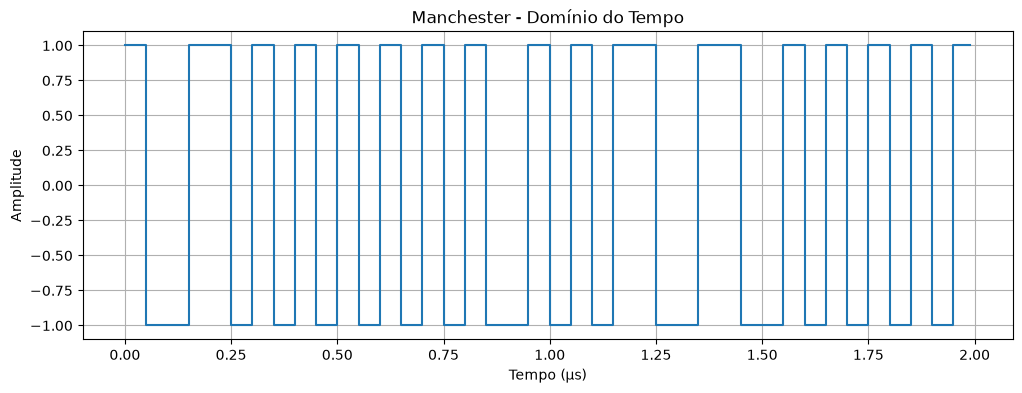

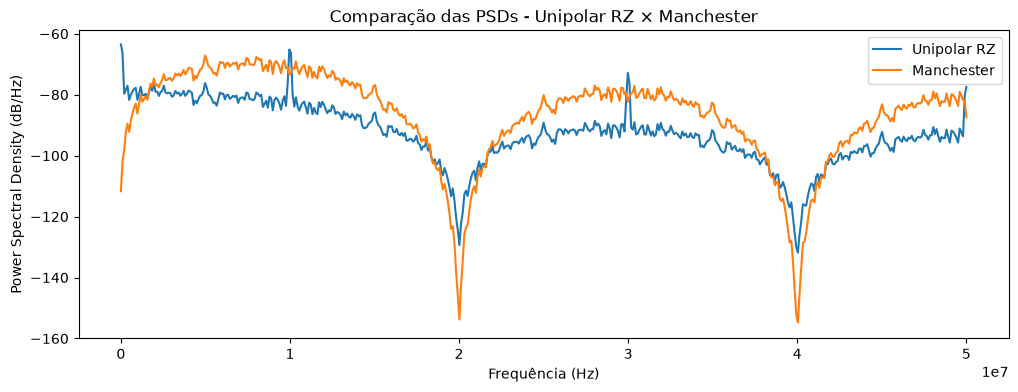

In [16]:
Rb = 10e6

sinal_manchester = manchester(bits, Rb, fs)

# Eixo de tempo
t = np.arange(len(sinal_manchester)) / fs

# -------------------------
# Domínio do tempo
# -------------------------
N_bits_plot = 20
N_amostras_plot = N_bits_plot * int(fs / Rb)

plt.figure(figsize=(12, 4))
plt.plot(
    t[:N_amostras_plot] * 1e6,
    sinal_manchester[:N_amostras_plot],
    drawstyle="steps-post"
)
plt.xlabel("Tempo (µs)")
plt.ylabel("Amplitude")
plt.title("Manchester - Domínio do Tempo")
plt.grid()
plt.show()

# -------------------------
# PSD - comparação com RZ
# -------------------------
plt.figure(figsize=(12, 4))

plt.psd(
    sinal_rz,
    Fs=fs,
    NFFT=1024,
    label="Unipolar RZ"
)

plt.psd(
    sinal_manchester,
    Fs=fs,
    NFFT=1024,
    label="Manchester"
)

plt.title("Comparação das PSDs - Unipolar RZ × Manchester")
plt.xlabel("Frequência (Hz)")
plt.legend()
plt.grid()
plt.show()

**Nulos espectrais observados (edite esta célula):**

- RZ: nulos em f = 20 MHz (e múltiplos de 20 MHz: 20, 40, 60, ... MHz)

- Manchester: nulos em f = 20 MHz (e múltiplos de 20 MHz: 20, 40, 60, ... MHz)

- Nos dois sinais, a estrutura dos pulsos faz com que as contribuições espectrais se cancelem  periodicamente nessas frequências. No RZ, o pulso ocupa metade do período, enquanto no Manchester existe uma transição obrigatória no meio de cada bit. Como resultado, os espectros apresentam nulos periódicos, observados no gráfico em aproximadamente 20 MHz e seus múltiplos.

## Parte 3 — Efeito do canal real (cabo CAT5 emulado)

Use o modelo de canal já disponibilizado em aula (`cat5_eth_channel.py`,
baseado na tabela de *Insertion Loss* do datasheet MPTcable CAT5e), com o
seu **comprimento de cabo individual** (`length_m` calculado no início do
notebook).

In [17]:
from cat5_eth_channel import cat5_channel, design_cat5_filter

1. Para cada codificação de linha da Parte 1 (não precisa repetir para
   Manchester), varie a taxa de transmissão `Rb` em **10, 40 e 100 Mbps** e
   passe o sinal codificado pelo canal emulado. Cole no relatório os
   gráficos do sinal **recebido** (após o canal) no tempo e na frequência,
   para as três taxas.

In [18]:
# Nao funcionaria com o fs anterior
fs_canal = 500e6

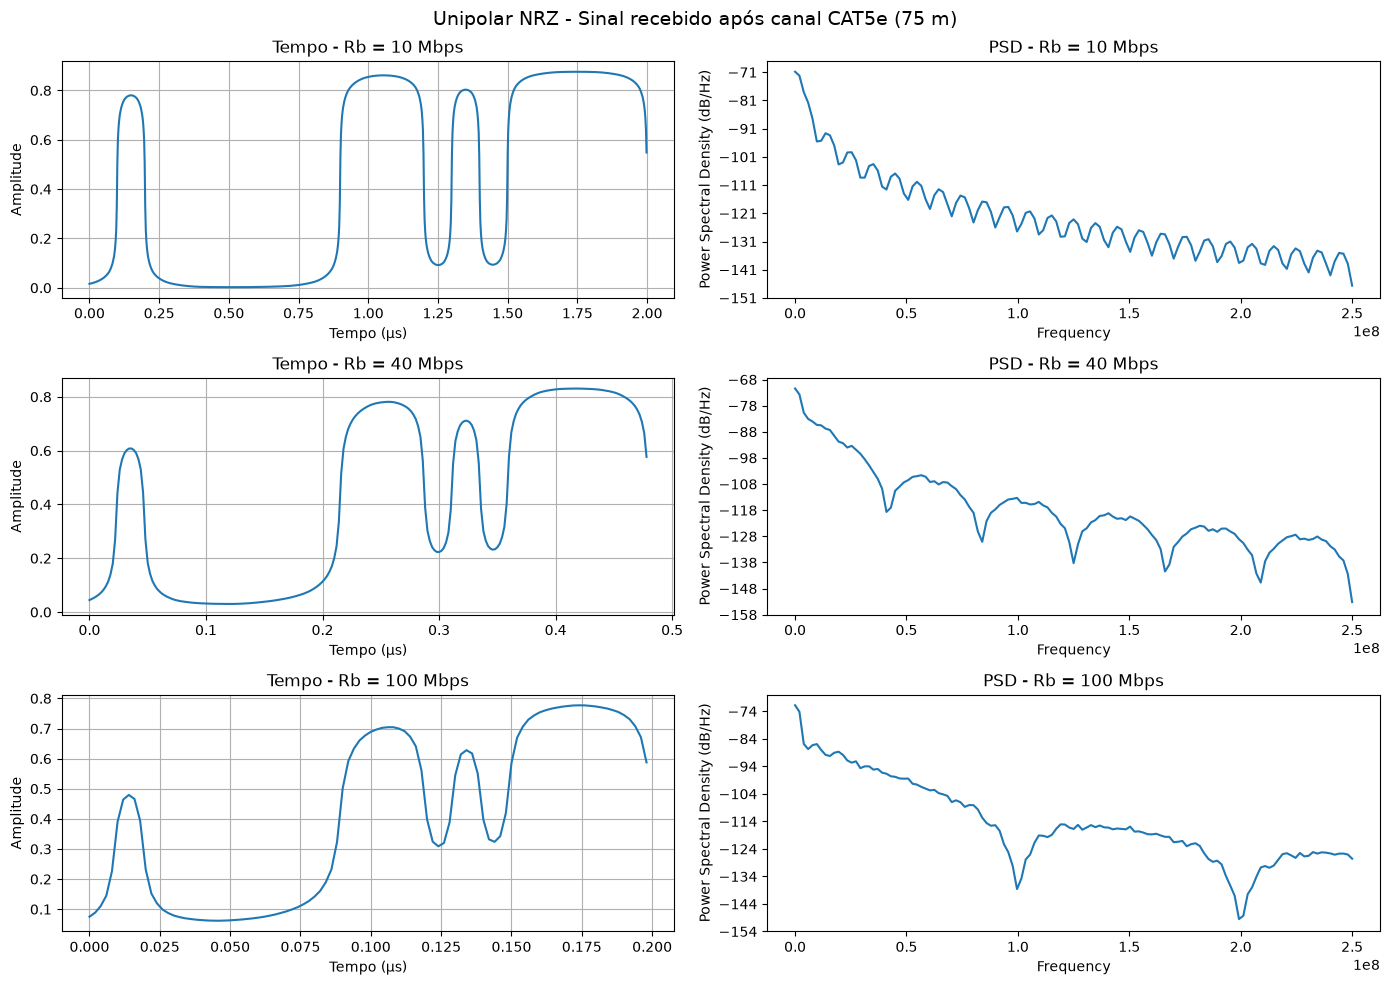

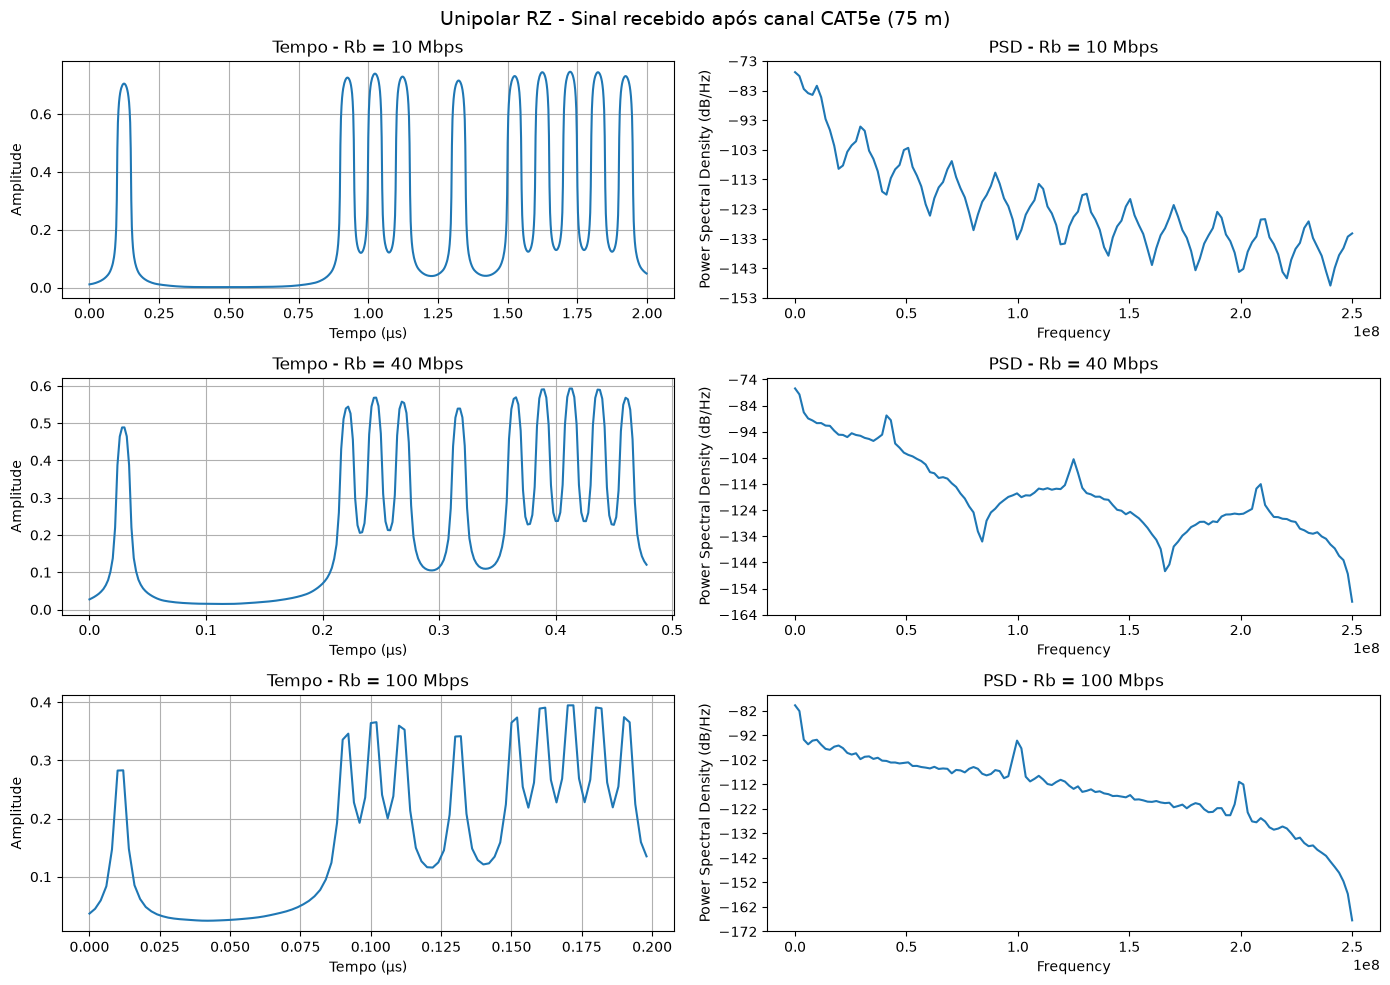

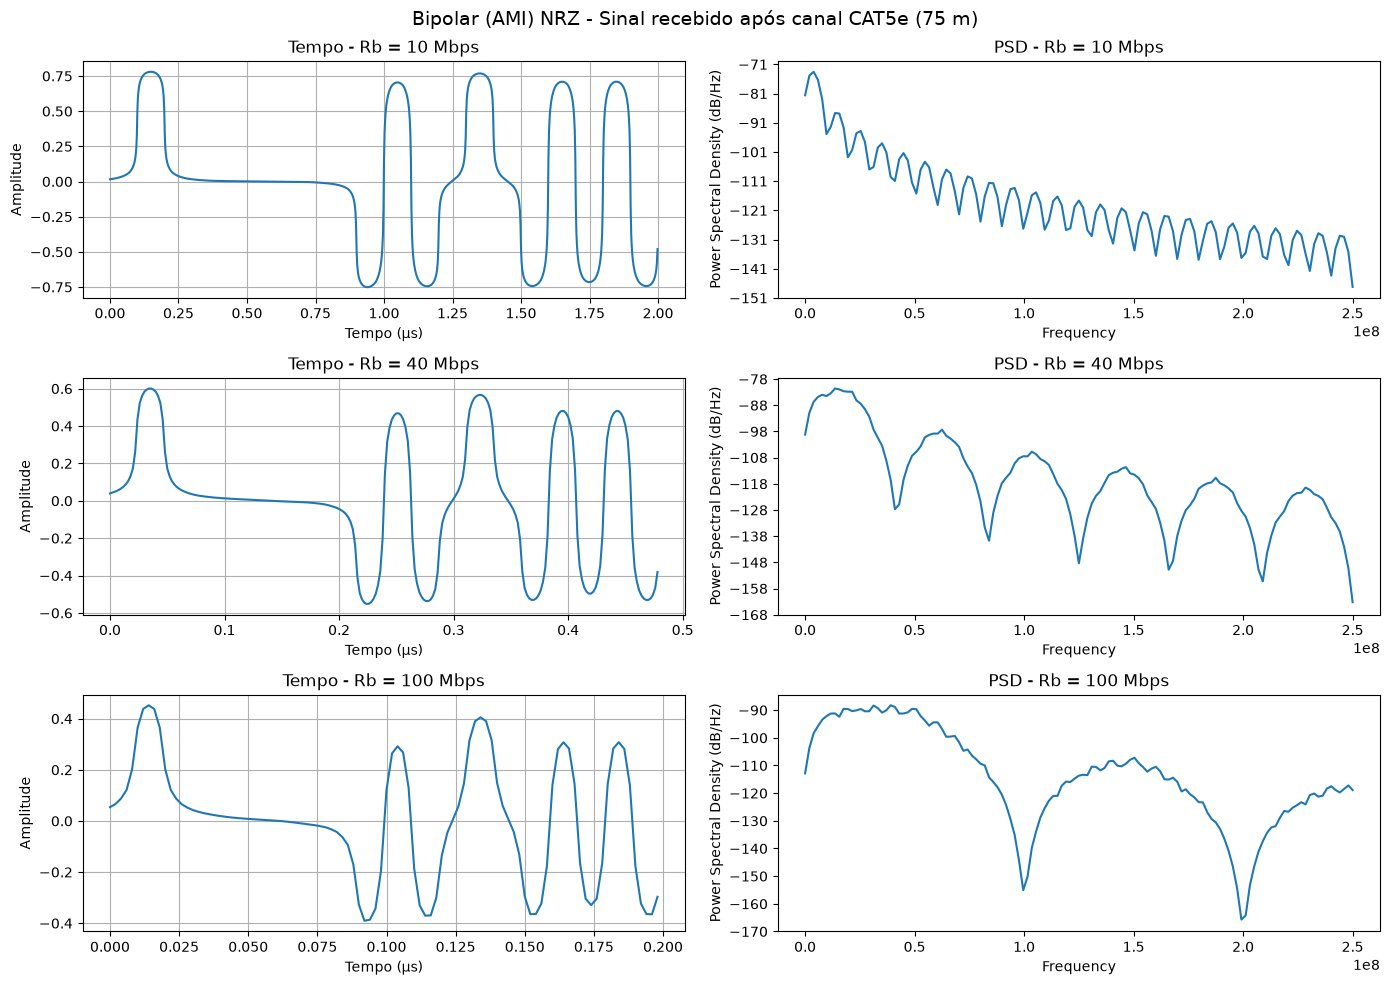

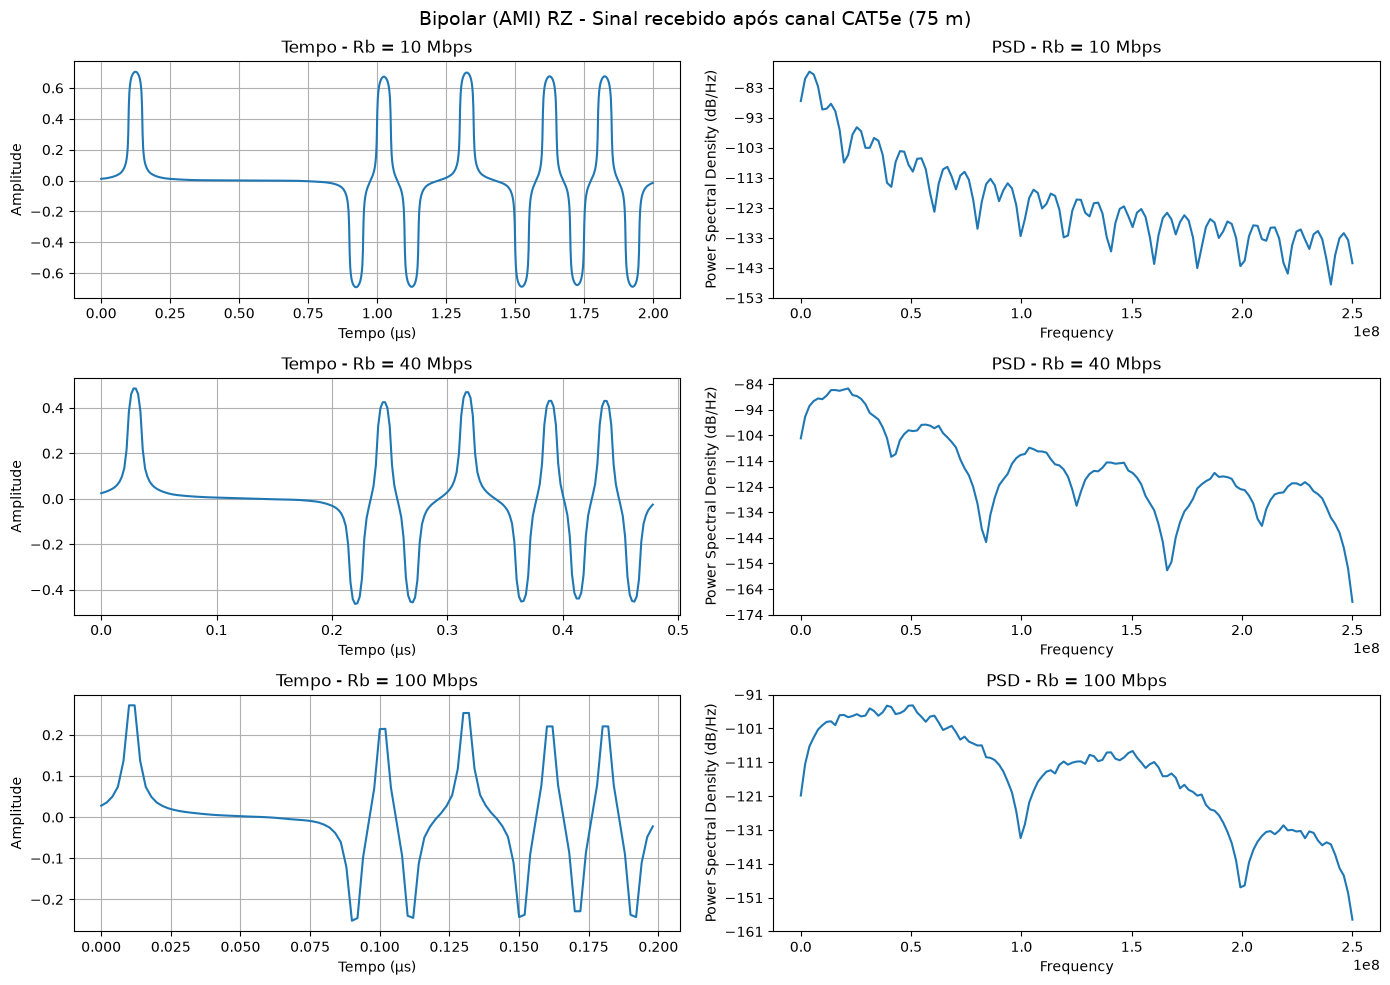

In [19]:
Rb_valores = [10e6, 40e6, 100e6]

codificacoes = {
    "Unipolar NRZ": unipolar_nrz,
    "Unipolar RZ": unipolar_rz,
    "Bipolar (AMI) NRZ": bipolar_nrz,
    "Bipolar (AMI) RZ": bipolar_rz
}

for nome, codificador in codificacoes.items():

    fig, axes = plt.subplots(
        len(Rb_valores), 2,
        figsize=(14, 10)
    )

    fig.suptitle(
        f"{nome} - Sinal recebido após canal CAT5e ({length_m} m)",
        fontsize=14
    )

    for i, Rb in enumerate(Rb_valores):

        # Codificação
        sinal = codificador(bits, Rb, fs_canal)

        # Canal CAT5e
        sinal_recebido = cat5_channel(
            sinal,
            fs_canal,
            length_m
        )

        # Compensação do atraso de grupo do FIR
        atraso = (513 - 1) // 2
        sinal_recebido_plot = sinal_recebido[atraso:]

        # Eixo de tempo
        t = np.arange(len(sinal_recebido_plot)) / fs_canal

        # -------------------------
        # Sinal no tempo
        # -------------------------

        N_bits_plot = 20
        N_amostras_plot = N_bits_plot * int(fs_canal / Rb)

        axes[i, 0].plot(
            t[:N_amostras_plot] * 1e6,
            sinal_recebido_plot[:N_amostras_plot]
        )

        axes[i, 0].set_title(
            f"Tempo - Rb = {Rb/1e6:.0f} Mbps"
        )

        axes[i, 0].set_xlabel("Tempo (µs)")
        axes[i, 0].set_ylabel("Amplitude")
        axes[i, 0].grid()

        # -------------------------
        # PSD
        # -------------------------

        axes[i, 1].psd(
            sinal_recebido,
            Fs=fs_canal
        )

        axes[i, 1].set_title(
            f"PSD - Rb = {Rb/1e6:.0f} Mbps"
        )

        axes[i, 1].grid()

    plt.tight_layout()
    plt.show()

2. Compare o sinal recebido com o sinal transmitido (antes do canal) nos
   dois domínios. Descreva o que muda visualmente entre 10, 40 e 100 Mbps.

*No domínio do tempo, o sinal recebido apresenta redução da amplitude e distorção das transições em relação ao sinal transmitido. Essas alterações ficam mais evidentes conforme a taxa aumenta de 10 para 40 e 100 Mbps.*

*No domínio da frequência, observa-se uma redução da potência espectral, principalmente nas componentes de maior frequência. Em taxas maiores, o sinal ocupa uma faixa espectral mais larga e, como o cabo apresenta maior atenuação em frequências mais altas, essas componentes são mais afetadas.*

3. **Por que**, ao aumentar a taxa de transmissão, o sinal recebido passa a
   apresentar mais distorção? Relacione sua resposta com o que você observou
   sobre a largura dos lóbulos espectrais na Parte 2 e com a curva de
   atenuação do cabo (que cresce com a frequência).

*Ao aumentar a taxa de transmissão, os símbolos ficam mais curtos e o sinal passa a ocupar uma faixa de frequências maior. O cabo CAT5e apresenta uma atenuação que aumenta com a frequência, portanto as componentes de alta frequência do sinal sofrem maior atenuação durante a transmissão. Dessa forma, quanto maior a taxa de transmissão, maior a quantidade de componentes espectrais afetadas pelo canal, resultando em maior distorção e redução da amplitude do sinal recebido.*

4. Dependendo da codificação de linha e da taxa de transmissão, o primeiro
   lóbulo do sinal no domínio da frequência ocupa uma faixa mais larga ou
   mais estreita. **Qual a relevância prática disso** num meio físico cuja
   atenuação aumenta com a frequência do sinal em banda base? Ou seja: a
   *escolha da codificação de linha* é indiferente para a integridade do
   sinal recebido, ou algumas codificações sofrem mais que outras no mesmo
   cabo e na mesma taxa? Justifique com base nos gráficos.

*Nos gráficos da parte 2, observa-se que as diferentes codificações apresentam larguras e distribuições espectrais diferentes. Assim, uma codificação cujo primeiro lóbulo ocupa uma faixa de frequências mais larga utiliza mais componentes de alta frequência e, consequentemente, pode sofrer maior atenuação e distorção ao atravessar o cabo.*

*Então não, a escolha não é indiferente, pois a codificação pode ser afetada de forma diferente.*

5. **E se...?** Repita a análise do item 1 (mesma taxa, mesma codificação)
   emulando um cabo com metade do seu comprimento individual. O que muda no
   sinal recebido, e isso é coerente com o modelo de atenuação linear em dB
   por metro que vimos em aula? Explique em poucas linhas — não precisa
   colar todos os gráficos de novo, só o suficiente para sustentar a
   resposta.

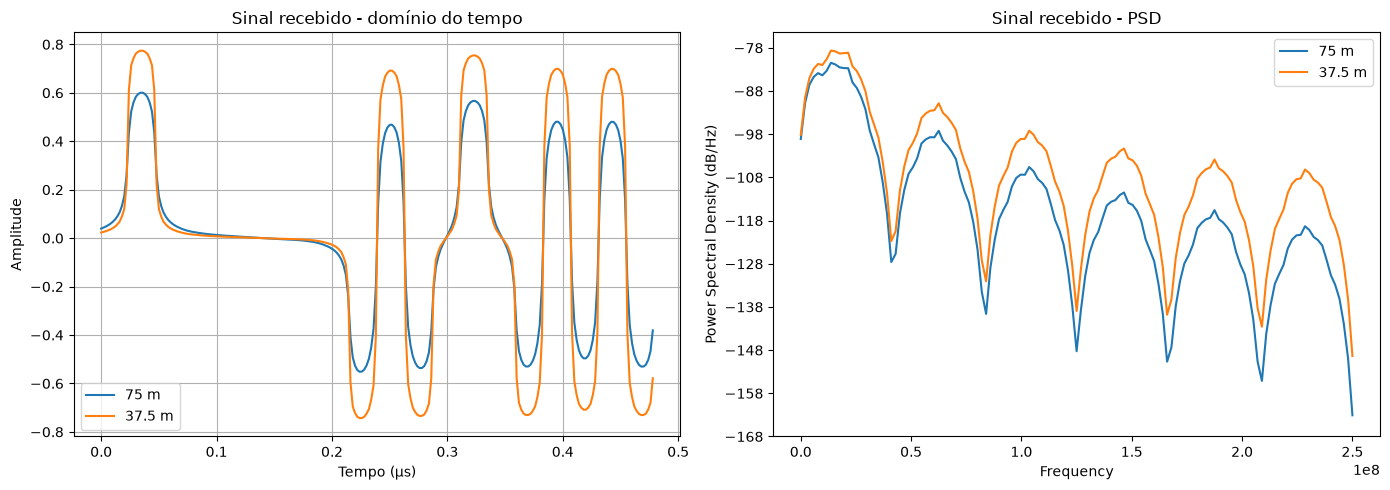

In [20]:
# Escolha da codificação e taxa
Rb_teste = 40e6
codificador_teste = bipolar_nrz

# Sinal transmitido
sinal = codificador_teste(bits, Rb_teste, fs_canal)

# Canal com comprimento original
sinal_75m = cat5_channel(
    sinal,
    fs_canal,
    length_m
)

# Canal com metade do comprimento
sinal_37_5m = cat5_channel(
    sinal,
    fs_canal,
    length_m / 2
)

# Compensação do atraso do FIR
atraso = (513 - 1) // 2

sinal_75m = sinal_75m[atraso:]
sinal_37_5m = sinal_37_5m[atraso:]

# Eixo de tempo
t = np.arange(len(sinal_75m)) / fs_canal

# Número de amostras para visualizar 20 bits
N_bits_plot = 20
N_amostras_plot = N_bits_plot * int(fs_canal / Rb_teste)

# -------------------------
# Gráficos
# -------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tempo
axes[0].plot(
    t[:N_amostras_plot] * 1e6,
    sinal_75m[:N_amostras_plot],
    label=f"{length_m} m"
)

axes[0].plot(
    t[:N_amostras_plot] * 1e6,
    sinal_37_5m[:N_amostras_plot],
    label=f"{length_m/2:.1f} m"
)

axes[0].set_title("Sinal recebido - domínio do tempo")
axes[0].set_xlabel("Tempo (µs)")
axes[0].set_ylabel("Amplitude")
axes[0].grid()
axes[0].legend()

# PSD
axes[1].psd(
    sinal_75m,
    Fs=fs_canal,
    label=f"{length_m} m"
)

axes[1].psd(
    sinal_37_5m,
    Fs=fs_canal,
    label=f"{length_m/2:.1f} m"
)

axes[1].set_title("Sinal recebido - PSD")
axes[1].grid()
axes[1].legend()

plt.tight_layout()
plt.show()

*Ao reduzir o comprimento do cabo de 75 m para 37,5 m, o sinal recebido apresenta menor atenuação e menor distorção, mantendo uma amplitude maior e mais energia espectral, principalmente nas frequências mais altas. Isso é coerente com o modelo de atenuação do cabo, pois a perda é aproximadamente linear com o comprimento em dB. Assim, ao reduzir o comprimento pela metade, a atenuação também é aproximadamente reduzida pela metade em dB.*

## Entregáveis

- Este notebook preenchido (código, gráficos e respostas em markdown).
- Certifique-se de que os dois parâmetros individuais (seed e length_m)
  aparecem corretamente calculados no início do notebook.

